# Experiments
## RandomAlgorithm experiment

### Read configuration


### Plot RandomAlgorithm Experiment

# All algorithm comparison test

## Read algorithm comparison experiment configuration

In [2]:
from notebook_helpers import *

experiment_name = "tai_all_default_all_algorithms"
_, config_path, out_dir, results_csv, _ = run_experiment(experiment_name)

print(f"Config: {config_path}")
print(f"Output dir: {out_dir}")
print(f"Results CSV: {results_csv}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_all_algorithms\experimentrunner.json
Config: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_all_algorithms\experimentrunner.json
Output dir: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_all_algorithms
Results CSV: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_all_algorithms\experiment_results.csv


## Plot all algorithm comparison

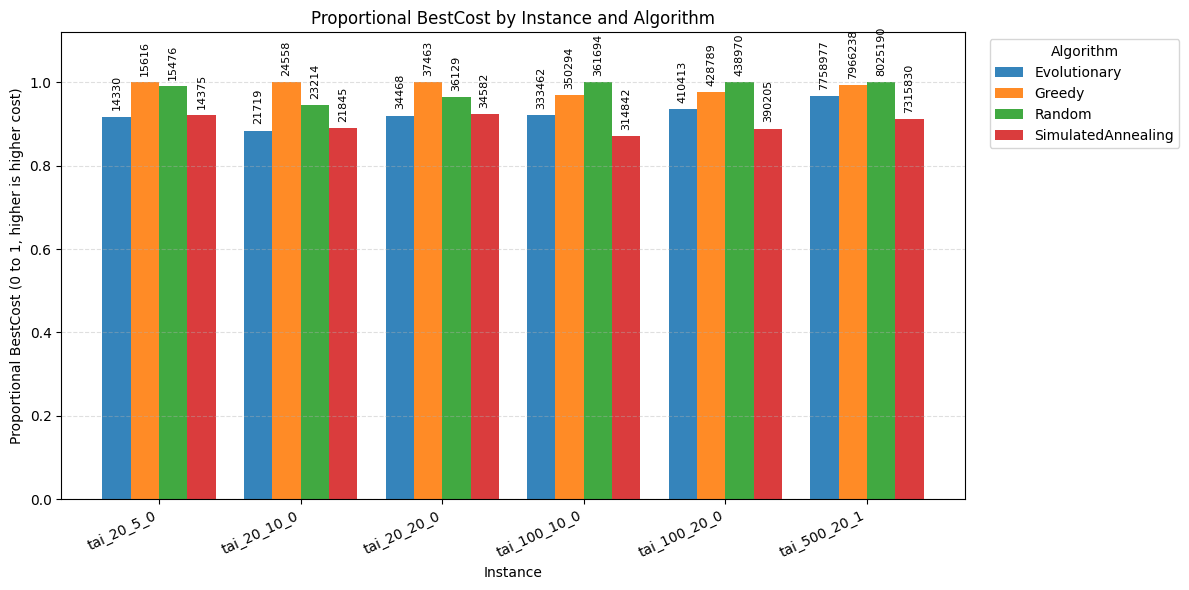

In [3]:
from notebook_helpers import *

experiment_name = "tai_all_default_all_algorithms"
df = read_results_table(experiment_name)

instance_order = df["Instance"].drop_duplicates().tolist()
df["Algorithm"] = df["Algorithm"].transform(lambda s: s.split("_")[0])  # Keep only the last part of the algorithm name.
df["MeanBestCost"] = df.groupby(["Instance", "Algorithm"])["Best.Cost"].transform("mean")

pivot = df.pivot_table(
    index="Instance",
    columns="Algorithm",
    values="MeanBestCost",
    aggfunc="min",
).reindex(instance_order)

row_max = pivot.max(axis=1).replace(0, np.nan)
score_pivot = pivot.div(row_max, axis=0).fillna(0.0)

instances = score_pivot.index.to_list()
algorithms = score_pivot.columns.to_list()
x = np.arange(len(instances))
width = 0.8 / max(len(algorithms), 1)

fig, ax = plt.subplots(figsize=(12, 6))
for idx, alg in enumerate(algorithms):
    offset = (idx - (len(algorithms) - 1) / 2) * width
    heights = score_pivot[alg].values
    bars = ax.bar(x + offset, heights, width=width, label=alg, alpha=0.9)

    for bar, cost in zip(bars, pivot[alg].values):
        if pd.notna(cost):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{int(cost)}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(instances, rotation=25, ha="right")
ax.set_xlabel("Instance")
ax.set_ylabel("Proportional BestCost (0 to 1, higher is higher cost)")
ax.set_title("Proportional BestCost by Instance and Algorithm")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Algorithm", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 2 Parameter Evolutionary test

## Run 2D evolutionary experiment

In [13]:
from notebook_helpers import *

experiment_name = "tai_20_5_0_evolutionary_population_generations_2d_256"
_, config_path, out_dir, _, results_json = run_experiment(experiment_name)

print(f"Config: {config_path}")
print(f"Output dir: {out_dir}")
print(f"Results JSON: {results_json}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_20_5_0_evolutionary_population_generations_2d_256\experimentrunner.json
Config: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_20_5_0_evolutionary_population_generations_2d_256\experimentrunner.json
Output dir: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_20_5_0_evolutionary_population_generations_2d_256
Results JSON: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_20_5_0_evolutionary_population_generations_2d_256\experiment_results.json


## Plot 2D Pop/Gen experiment

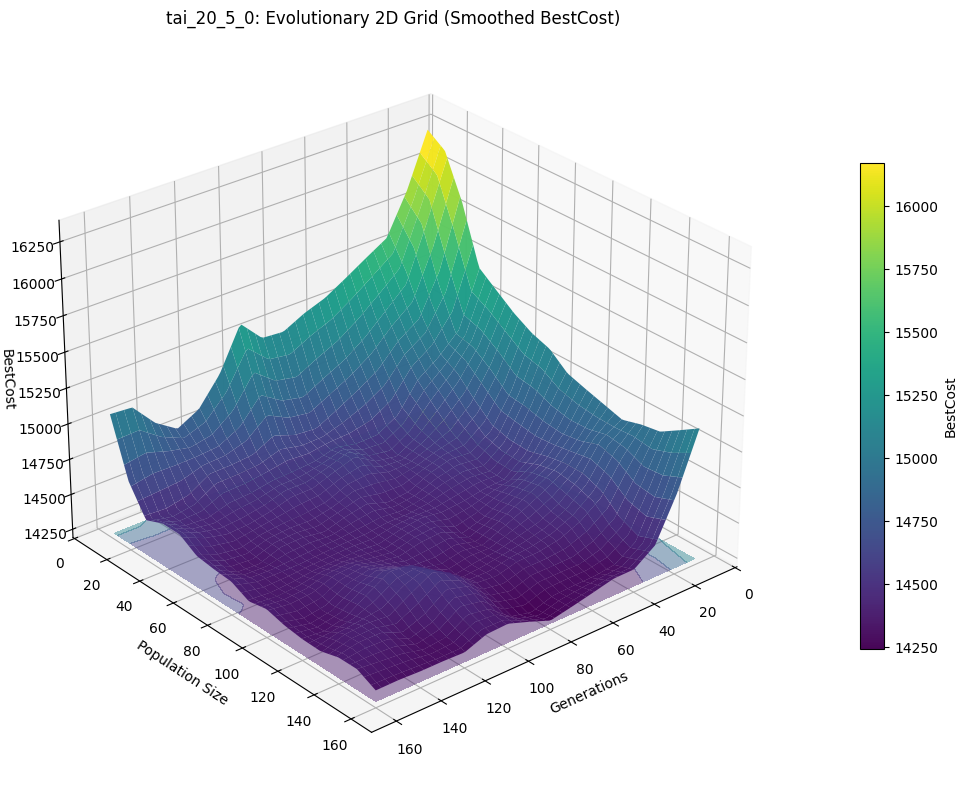

In [5]:
from notebook_helpers import *

if RegularGridInterpolator is None or gaussian_filter is None:
    raise RuntimeError("scipy is required for this plot. Install scipy in the notebook environment.")

experiment_name = "tai_20_5_0_evolutionary_population_generations_2d_256"
df = read_results_table(experiment_name)

if "BestCost" not in df.columns and "Best.Cost" in df.columns:
    df = df.rename(columns={"Best.Cost": "BestCost"})

df = df[df["Instance"] == "tai_20_5_0"].copy()

# Support both compact names (Evolutionary_p64_g256_s42) and full names
pattern = re.compile(
    r"Evolutionary(?:_Seed\d+)?(?:_PopulationSize(?P<p1>\d+)_Generations(?P<g1>\d+)|_p(?P<p2>\d+)_g(?P<g2>\d+))"
)
parsed = df["Algorithm"].str.extract(pattern)
df["PopulationSize"] = pd.to_numeric(parsed["p1"].fillna(parsed["p2"]), errors="coerce")
df["Generations"] = pd.to_numeric(parsed["g1"].fillna(parsed["g2"]), errors="coerce")
df = df.dropna(subset=["PopulationSize", "Generations", "BestCost"]).copy()

df["PopulationSize"] = df["PopulationSize"].astype(int)
df["Generations"] = df["Generations"].astype(int)

surface_df = df.pivot_table(
    index="Generations", columns="PopulationSize", values="BestCost", aggfunc="min"
).sort_index().sort_index(axis=1)

if surface_df.empty:
    raise ValueError(
        "No Evolutionary PopulationSize/Generations data found for this experiment after filtering."
    )

g_vals = surface_df.index.to_numpy(dtype=float)
p_vals = surface_df.columns.to_numpy(dtype=float)
Z = surface_df.to_numpy(dtype=float)

Z_smooth = gaussian_filter(Z, sigma=0.8)
p_dense = np.linspace(p_vals.min(), p_vals.max(), 120)
g_dense = np.linspace(g_vals.min(), g_vals.max(), 120)
P_dense, G_dense = np.meshgrid(p_dense, g_dense)

interp = RegularGridInterpolator((g_vals, p_vals), Z_smooth, method="linear")
pts = np.column_stack([G_dense.ravel(), P_dense.ravel()])
Z_dense = interp(pts).reshape(G_dense.shape)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
ax.contourf(G_dense, P_dense, Z_dense, zdir="z", offset=np.nanmin(Z_dense), cmap="viridis", alpha=0.45)
surf = ax.plot_surface(G_dense, P_dense, Z_dense, cmap="viridis", edgecolor="none", antialiased=True, alpha=0.98)

ax.set_xlabel("Generations")
ax.set_ylabel("Population Size")
ax.set_zlabel("BestCost")
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_title("tai_20_5_0: Evolutionary 2D Grid (Smoothed BestCost)")
ax.view_init(elev=28, azim=-130)

cbar = fig.colorbar(surf, shrink=0.65, pad=0.08)
cbar.set_label("BestCost")
plt.tight_layout()
plt.show()

# SimulatedAnnealing neighbor operators

## Run experiment: all instances Ă— all neighbor operators

In [ ]:
from notebook_helpers import *

experiment_name = "tai_all_default_simulatedannealing_neighbors_seed"
_, config_path, out_dir, _, results_json = run_experiment(experiment_name)

print(f"Config: {config_path}")
print(f"Output dir: {out_dir}")
print(f"Results JSON: {results_json}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_simulatedannealing_neighbors_seed\experimentrunner.json
Config: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_simulatedannealing_neighbors_seed\experimentrunner.json
Output dir: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_simulatedannealing_neighbors_seed
Results CSV: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_simulatedannealing_neighbors_seed\experiment_results.csv


## Plot SA neighbor operator comparison

In [10]:
from notebook_helpers import *

experiment_name = "tai_all_default_simulatedannealing_neighbors_seed"
df = read_results_table(experiment_name)

if "BestCost" not in df.columns and "Best.Cost" in df.columns:
    df = df.rename(columns={"Best.Cost": "BestCost"})

pattern = re.compile(
    r"SimulatedAnnealing(?:_Seed(?P<Seed>\d+))?.*?NeighborhoodOperator(?P<Neighbor>Swap|Insert|Reverse)",
    re.IGNORECASE,
 )
parsed = df["Algorithm"].str.extract(pattern)
df["Neighbor"] = parsed["Neighbor"].str.title()
df["Seed"] = pd.to_numeric(parsed["Seed"], errors="coerce").fillna(0).astype(int)
df = df.dropna(subset=["Neighbor", "BestCost"]).copy()

if df.empty:
    raise RuntimeError("No SimulatedAnnealing rows parsed for neighbor comparison.")

instance_order = df["Instance"].drop_duplicates().tolist()
operator_order = ["Swap", "Insert", "Reverse"]

mean_by_seed = df.groupby(["Instance", "Neighbor"], as_index=False)["BestCost"].mean()
pivot = mean_by_seed.pivot(index="Instance", columns="Neighbor", values="BestCost").reindex(index=instance_order, columns=operator_order)

row_max = pivot.max(axis=1).replace(0, np.nan)
score_pivot = pivot.div(row_max, axis=0).fillna(0.0)

x = np.arange(len(instance_order))
width = 0.8 / len(operator_order)
bar_colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(12, 6))
for idx, op in enumerate(operator_order):
    offset = (idx - (len(operator_order) - 1) / 2) * width
    heights = score_pivot[op].values
    bars = ax.bar(x + offset, heights, width=width, label=op, alpha=0.9, color=bar_colors[idx])

    for bar, val in zip(bars, pivot[op].values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{int(val)}",
                ha="center", va="bottom", fontsize=8, rotation=90,
            )

ax.set_xticks(x)
ax.set_xticklabels(instance_order, rotation=25, ha="right")
ax.set_xlabel("Instance")
ax.set_ylabel("Proportional BestCost (0 to 1, higher is higher cost)")
ax.set_title("SimulatedAnnealing: Mean BestCost across seeds by instance and neighbor operator")
ax.set_ylim(0, 1.12)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Neighbor operator")
plt.tight_layout()
plt.show()

score_pivot

RuntimeError: No SimulatedAnnealing rows parsed for neighbor comparison.

# TODOS

## General
* EA and SA additional heuristics
* Restart and barrier breaking
* IRACE?
* Measurement and metadata plug-in

## Experiment
* Generalize runner configuration even more
* DTO unification and cross-program setup
* Test averaging
* Algorithm runtime metadata - not only
* Ablation and other extras

## EA
* Implement different Mutation and Crossover operators
* Start from heuristic solution
* Roulette
* Fitness penalty

# SA
* Cooling schedule comparison

# Fix
* NEH running time
* Missing Random evals and test run
* Make sure Greedy runs once!

# Questions
* Problem formulation
* Should I also optimize SA?
* Computation load, stop conditions, stuck

## Monitor Every Event Example
Pattern: description -> run -> read/calculate/plot. Cells below are independent and can be executed without prior notebook state.

In [26]:
from notebook_helpers import *

experiment_name = "monitor_every_event_example"
_, config_path, out_dir, _, results_json = run_experiment(experiment_name)

print(f"Config: {config_path}")
print(f"Output dir: {out_dir}")
print(f"Results JSON: {results_json}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\monitor_every_event_example\experimentrunner.json
Experiment Runner
Running Evolutionary_Seed42_PopulationSize30_Generations20_ElitismK0_EvaluationBudget0_CrossoverRate0.70_MutationRate0.10_TournamentSize5_SelectionMethodTournament_CrossoverMethodOX_MutationMethodSwap on tai_20_5_0 (seed 42)...
Done. Results saved to C:\Users\szymo\source\repos\CichySA\Optimization_methods\monitor_every_event_example\experiment_results.json

Config: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\monitor_every_event_example\experimentrunner.json
Output dir: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\monitor_every_event_example
Results JSON: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\monitor_every_event_example\experiment_results.json


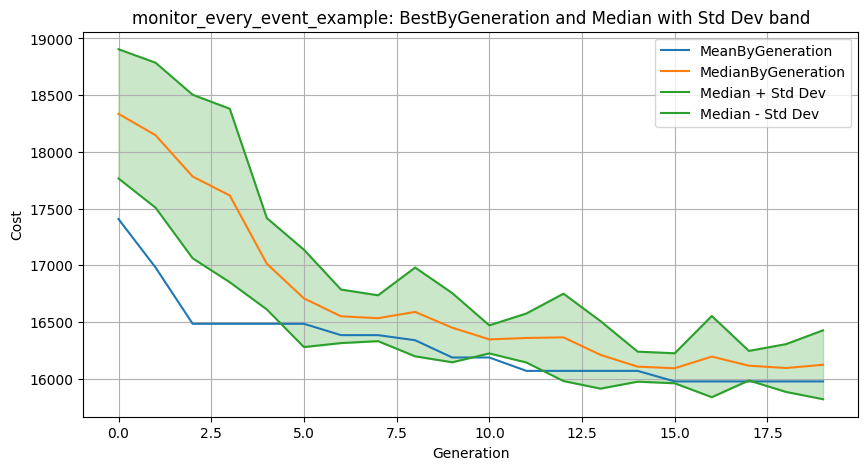

{'BestByGeneration': [17408.0,
  16981.0,
  16485.0,
  16485.0,
  16485.0,
  16485.0,
  16385.0,
  16385.0,
  16340.0,
  16188.0,
  16188.0,
  16070.0,
  16070.0,
  16070.0,
  16070.0,
  15977.0,
  15977.0,
  15977.0,
  15977.0,
  15977.0],
 'MeanByGeneration': [18335.5,
  18147.033333333333,
  17783.033333333333,
  17616.1,
  17014.266666666666,
  16709.0,
  16551.033333333333,
  16534.266666666666,
  16589.666666666668,
  16450.633333333335,
  16347.566666666668,
  16359.933333333332,
  16365.333333333334,
  16211.0,
  16107.3,
  16093.066666666668,
  16195.966666666667,
  16115.666666666666,
  16095.2,
  16123.833333333334],
 'DeviationByGeneration': [569.5712276206843,
  638.9950695340996,
  720.7615178098479,
  764.6628603508868,
  402.8500079296126,
  429.04203368279275,
  236.0050117170302,
  202.10425252549464,
  391.3264053901238,
  304.834543463973,
  123.64564511358881,
  215.97977271546102,
  384.99924963851845,
  297.48030747149187,
  132.340255906256,
  132.23462313462218

In [27]:
from notebook_helpers import *

experiment_name = "monitor_every_event_example"
details = read_results_json(experiment_name)
if not details:
    raise RuntimeError("Detailed results JSON is empty.")

exp = details[0]
metrics = exp.get("Metrics") or exp.get("ExperimentalData") or {}
best_by_gen = metrics.get("BestByGeneration")
median_by_gen = metrics.get("MeanByGeneration")
deviation_by_gen = metrics.get("DeviationByGeneration")

s_best = pd.Series(best_by_gen) if best_by_gen is not None else None
s_median = pd.Series(median_by_gen) if median_by_gen is not None else None
s_std = pd.Series(deviation_by_gen) if deviation_by_gen is not None else None

plt.figure(figsize=(10, 5))
if s_best is not None:
    s_best.plot(label="MeanByGeneration", color="C0")
if s_median is not None:
    s_median.plot(label="MedianByGeneration", color="C1")

if s_median is not None and s_std is not None:
    n = min(len(s_median), len(s_std))
    s_median = s_median.iloc[:n]
    s_std = s_std.iloc[:n]
    upper = s_median + s_std
    lower = s_median - s_std
    x = s_median.index

    upper.plot(label="Median + Std Dev", color="C2", linestyle="-")
    lower.plot(label="Median - Std Dev", color="C2", linestyle="-")
    plt.fill_between(x, lower.values, upper.values, color="C2", alpha=0.25)

plt.xlabel("Generation")
plt.ylabel("Cost")
plt.title("monitor_every_event_example: BestByGeneration and Median with Std Dev band")
plt.legend()
plt.grid(True)
plt.show()

metrics

## Monitor Every Event 2D
Run the experiment, then read results and plot the crossover-rate x mutation-rate surface. This block is independent.

In [28]:
from notebook_helpers import *

experiment_name = "monitor_every_event_example_2D"
_, config_path, out_dir, _, results_json = run_experiment(experiment_name)

print(f"Config: {config_path}")
print(f"Output dir: {out_dir}")
print(f"Results JSON: {results_json}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\monitor_every_event_example_2D\experimentrunner.json
Experiment Runner
Running Evolutionary_Seed4222_PopulationSize100_Generations100_ElitismK0_EvaluationBudget0_CrossoverRate0.70_MutationRate0.34_TournamentSize5_SelectionMethodTournament_CrossoverMethodOX_MutationMethodSwap on tai_20_5_0 (seed 4222)...
Running Evolutionary_Seed4222_PopulationSize100_Generations100_ElitismK0_EvaluationBudget0_CrossoverRate0.70_MutationRate0.28_TournamentSize5_SelectionMethodTournament_CrossoverMethodOX_MutationMethodSwap on tai_20_5_0 (seed 4222)...
Running Evolutionary_Seed4222_PopulationSize100_Generations100_ElitismK0_EvaluationBudget0_CrossoverRate0.60_MutationRate0.20_TournamentSize5_SelectionMethodTournament_CrossoverMethodOX_MutationMethodSwap on tai_20_5_0 (seed 4222)...
Running Evolutionary_Seed4222_PopulationSize100_Generations100_ElitismK0_EvaluationBudget0_Crossove

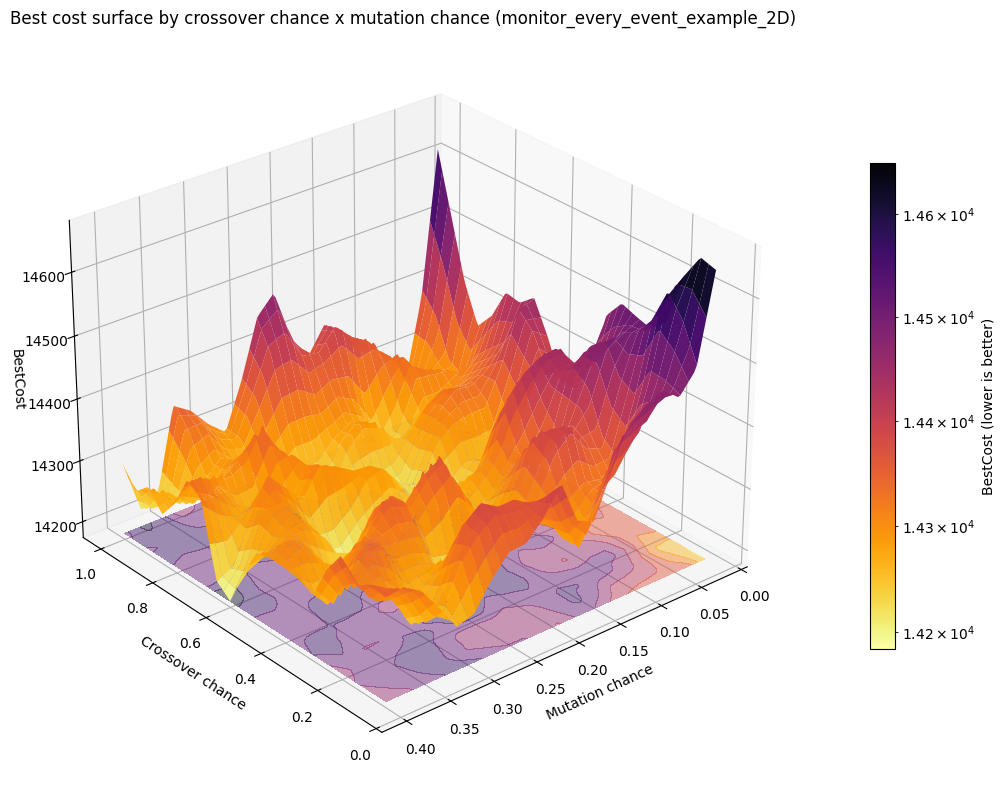

MutationRate,0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,0.18,0.20,0.22,0.24,0.26,0.28,0.30,0.32,0.34,0.36,0.38,0.40
CrossoverRate,,,,,,,,,,,,,,,,,,,,
0.05,14737.0,14350.0,14456.0,14585.0,14482.0,14458.0,14474.0,14348.0,14252.0,14575.0,14303.0,14310.0,14334.0,14302.0,14140.0,14232.0,14347.0,14323.0,14378.0,14312.0
0.10,14725.0,14509.0,14471.0,14324.0,14398.0,14604.0,14154.0,14189.0,14292.0,14401.0,14316.0,14408.0,14379.0,14307.0,14583.0,14182.0,14220.0,14353.0,14347.0,14423.0
0.15,14597.0,14820.0,14439.0,14468.0,14262.0,14221.0,14303.0,14180.0,14388.0,14333.0,14445.0,14349.0,14589.0,14417.0,14197.0,14275.0,14082.0,14367.0,14182.0,14283.0
0.20,14426.0,14633.0,14293.0,14238.0,14300.0,14300.0,14248.0,14408.0,14249.0,14264.0,14388.0,14239.0,14123.0,14381.0,14191.0,14288.0,14266.0,14369.0,14248.0,14503.0
0.25,14498.0,14534.0,14467.0,14255.0,14365.0,14553.0,14411.0,14220.0,14250.0,14148.0,14471.0,14078.0,14056.0,14254.0,14376.0,14174.0,14446.0,14473.0,14143.0,14404.0
0.30,14519.0,14454.0,14654.0,14322.0,14422.0,14434.0,14442.0,14374.0,14210.0,14311.0,14106.0,14153.0,14272.0,14457.0,14157.0,14387.0,14262.0,14371.0,14167.0,14237.0
0.35,14585.0,14340.0,14535.0,14624.0,14186.0,14083.0,14523.0,14300.0,14145.0,14394.0,14426.0,14373.0,14127.0,14365.0,14497.0,14342.0,14388.0,14255.0,14088.0,14404.0
0.40,14653.0,14232.0,14410.0,14306.0,14470.0,14258.0,14232.0,14203.0,14260.0,14150.0,14509.0,14493.0,14375.0,14395.0,14379.0,14115.0,14244.0,14229.0,14500.0,14213.0
0.45,14299.0,14483.0,14483.0,14563.0,14359.0,14659.0,14233.0,14400.0,14147.0,14400.0,14315.0,14158.0,14153.0,14290.0,14322.0,14121.0,14132.0,14381.0,14298.0,14286.0


In [29]:
from notebook_helpers import *

experiment_name = "monitor_every_event_example_2D"
data = read_results_json(experiment_name)

rows = []
for run in data:
    parameters = run.get("Parameters") or {}
    best = run.get("Best") or {}

    crossover_rate = parameters.get("CrossoverRate")
    mutation_rate = parameters.get("MutationRate")
    best_cost = best.get("Cost")

    if crossover_rate is None or mutation_rate is None or best_cost is None:
        continue

    rows.append({
        "CrossoverRate": float(crossover_rate),
        "MutationRate": float(mutation_rate),
        "BestCost": float(best_cost),
    })

if not rows:
    raise RuntimeError("No valid rows found with CrossoverRate, MutationRate, and Best.Cost.")

df = pd.DataFrame(rows)
surface_df = (
    df.groupby(["CrossoverRate", "MutationRate"], as_index=False)["BestCost"]
    .mean()
    .pivot(index="CrossoverRate", columns="MutationRate", values="BestCost")
    .sort_index()
    .sort_index(axis=1)
)

y_vals = surface_df.index.to_numpy(dtype=float)
x_vals = surface_df.columns.to_numpy(dtype=float)
Z = surface_df.to_numpy(dtype=float)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

if Z.shape[0] >= 2 and Z.shape[1] >= 2 and np.isfinite(Z).all():
    if RegularGridInterpolator is not None and gaussian_filter is not None:
        Z_smooth = gaussian_filter(Z, sigma=0.8)
        x_dense = np.linspace(x_vals.min(), x_vals.max(), 120)
        y_dense = np.linspace(y_vals.min(), y_vals.max(), 120)
        X_dense, Y_dense = np.meshgrid(x_dense, y_dense)

        interp = RegularGridInterpolator((y_vals, x_vals), Z_smooth, method="linear")
        pts = np.column_stack([Y_dense.ravel(), X_dense.ravel()])
        Z_dense = interp(pts).reshape(Y_dense.shape)

        ax.contourf(X_dense, Y_dense, Z_dense, zdir="z", offset=np.nanmin(Z_dense), cmap="inferno", alpha=0.45)
        surf = ax.plot_surface(
            X_dense,
            Y_dense,
            Z_dense,
            cmap="inferno_r",
            norm=colors.LogNorm(vmin=np.nanmin(Z_dense), vmax=np.nanmax(Z_dense)),
            edgecolor="none",
            antialiased=True,
            alpha=0.98,
        )
    else:
        X, Y = np.meshgrid(x_vals, y_vals)
        ax.contourf(X, Y, Z, zdir="z", offset=np.nanmin(Z), cmap="viridis", alpha=0.45)
        surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", antialiased=True, alpha=0.98)

    cbar = fig.colorbar(surf, shrink=0.65, pad=0.08)
    cbar.set_label("BestCost (lower is better)")
else:
    x0 = x_vals[0]
    y0 = y_vals[0]
    z0 = float(Z[0, 0])
    ax.scatter([x0], [y0], [z0], color="#ff7f0e", s=80)
    ax.text(x0, y0, z0, f" {int(z0)}", color="black")

ax.set_xlabel("Mutation chance")
ax.set_ylabel("Crossover chance")
ax.set_zlabel("BestCost")
ax.invert_xaxis()
ax.set_title("Best cost surface by crossover chance x mutation chance (monitor_every_event_example_2D)")
ax.view_init(elev=28, azim=-130)

plt.tight_layout()
plt.show()

surface_df

## EA Population/Generations (All Default)
Run the experiment, then read JSON and plot per-instance surfaces. This block is independent.

In [6]:
from notebook_helpers import *

experiment_name = "tai_all_default_evolutionary_population_generations_2d_64"
_, config_path, out_dir, _, results_json = run_experiment(experiment_name)

print(f"Config: {config_path}")
print(f"Output dir: {out_dir}")
print(f"Results JSON: {results_json}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_evolutionary_population_generations_2d_64\experimentrunner.json
Config: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_evolutionary_population_generations_2d_64\experimentrunner.json
Output dir: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_evolutionary_population_generations_2d_64
Results JSON: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_evolutionary_population_generations_2d_64\experiment_results.json


c:\Users\szymo\source\repos\CichySA\Optimization_methods\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


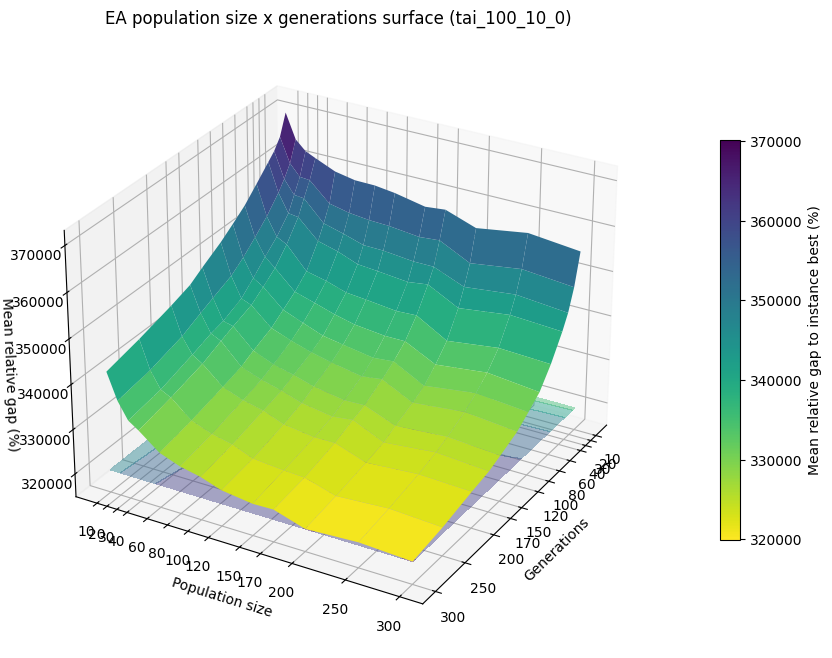

c:\Users\szymo\source\repos\CichySA\Optimization_methods\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


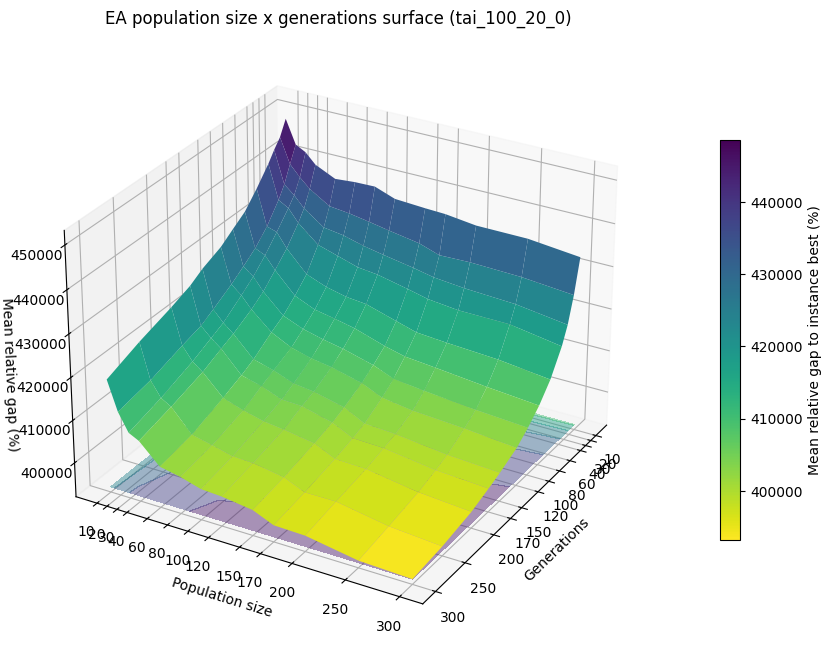

c:\Users\szymo\source\repos\CichySA\Optimization_methods\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


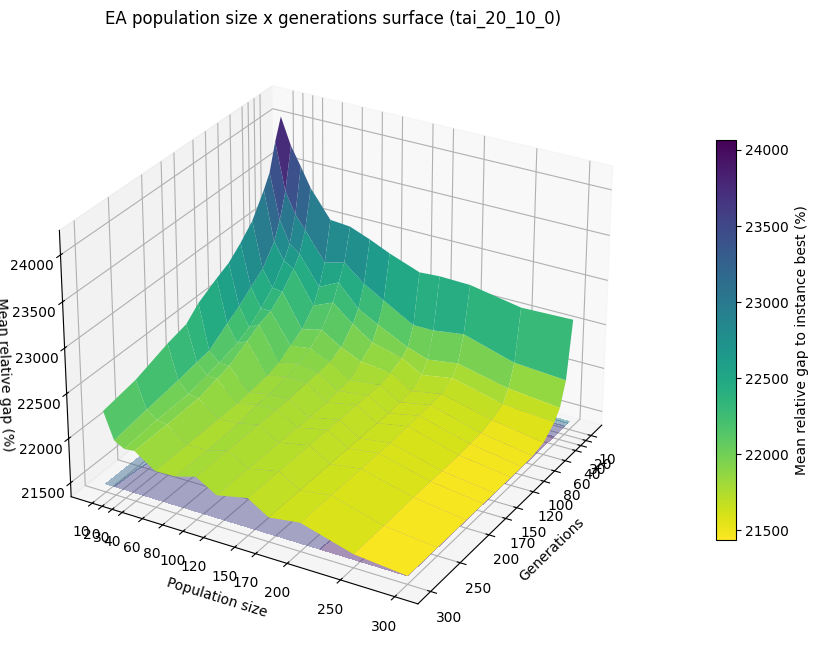

c:\Users\szymo\source\repos\CichySA\Optimization_methods\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


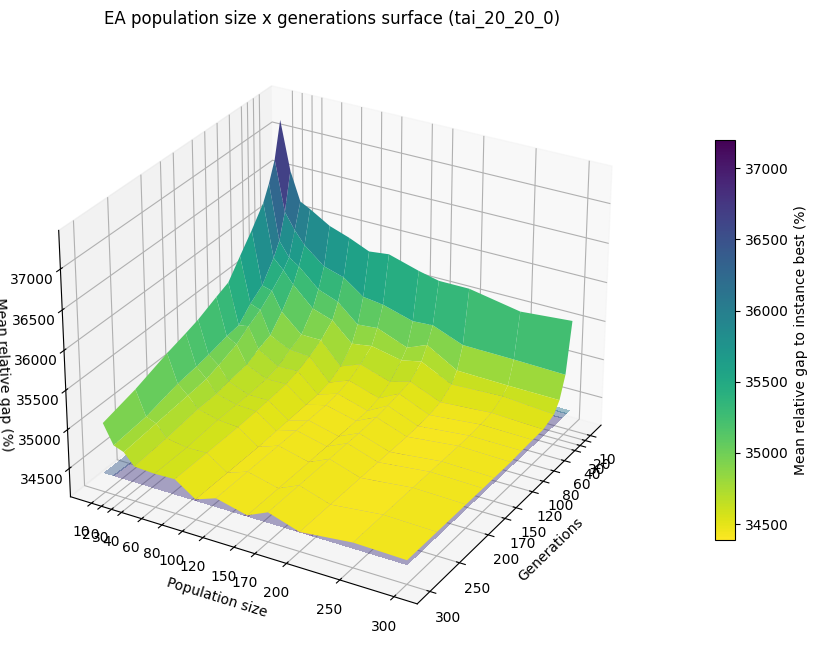

c:\Users\szymo\source\repos\CichySA\Optimization_methods\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


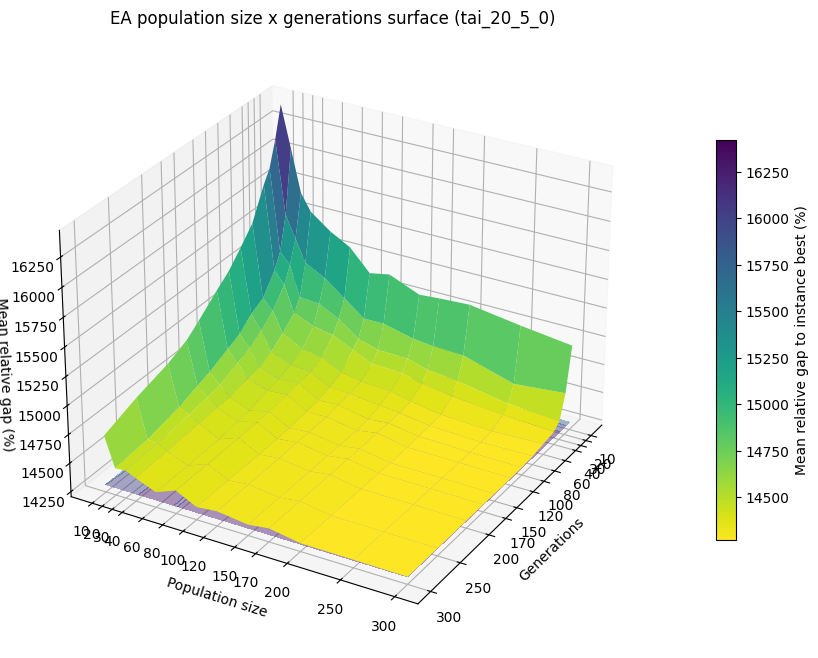

c:\Users\szymo\source\repos\CichySA\Optimization_methods\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


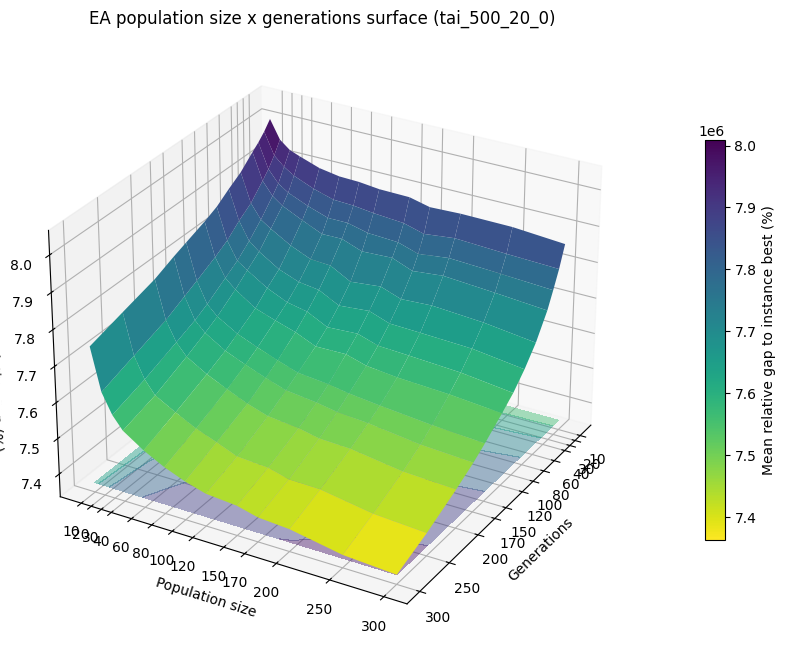

In [2]:
from notebook_helpers import *

experiment_name = "tai_all_default_evolutionary_population_generations_2d_64"
data = read_results_json(experiment_name)

rows = []
for run in data:
    parameters = run.get("Parameters") or {}
    best = run.get("Best") or {}

    population_size = parameters.get("PopulationSize")
    generations = parameters.get("Generations")
    best_cost = best.get("Cost")
    instance_name = run.get("Instance")

    if population_size is None or generations is None or best_cost is None or not instance_name:
        continue

    rows.append({
        "Instance": str(instance_name),
        "PopulationSize": int(population_size),
        "Generations": int(generations),
        "BestCost": float(best_cost),
    })

if not rows:
    raise RuntimeError("No valid rows found with PopulationSize, Generations, and Best.Cost.")

df = pd.DataFrame(rows)
df["InstanceMeanBest"] = df.groupby("Instance")["BestCost"].transform("min")
df["RelativeGapPct"] = df["InstanceMeanBest"].div(df["BestCost"]).sub(1.0).mul(100.0)


def plot_instance_surface(instance_df, instance_name, value_col="BestCost"):
    surface_df = (
        instance_df.groupby(["Generations", "PopulationSize"], as_index=False)[value_col]
        .mean()
        .pivot(index="Generations", columns="PopulationSize", values=value_col)
        .sort_index()
        .sort_index(axis=1)
    )

    g_vals = surface_df.index.to_numpy(dtype=float)
    p_vals = surface_df.columns.to_numpy(dtype=float)
    Z = surface_df.to_numpy(dtype=float)

    fig = plt.figure(figsize=(12, 8), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")

    if Z.shape[0] >= 2 and Z.shape[1] >= 2 and np.isfinite(Z).all():
        P_vals, G_vals = np.meshgrid(p_vals, g_vals)
        z_min = float(np.nanmin(Z))
        z_max = float(np.nanmax(Z))
        norm = colors.Normalize(vmin=z_min, vmax=z_max) if z_max > z_min else None

        ax.contourf(G_vals, P_vals, Z, zdir="z", offset=z_min, cmap="viridis", alpha=0.45)
        surf = ax.plot_surface(G_vals, P_vals, Z, cmap="viridis_r", norm=norm, edgecolor="none", antialiased=True, alpha=1)
        cbar = fig.colorbar(surf, shrink=0.65, pad=0.08)
        cbar.set_label("Mean relative gap to instance best (%)")
    else:
        g0 = g_vals[0]
        p0 = p_vals[0]
        z0 = float(Z[0, 0])
        ax.scatter([g0], [p0], [z0], color="#ff7f0e", s=80)
        ax.text(g0, p0, z0, f" {z0:.3f}%", color="black")

    ax.set_xlabel("Generations")
    ax.set_ylabel("Population size")
    ax.set_xticks(g_vals)
    ax.set_xticklabels([str(int(v)) for v in g_vals])
    ax.set_yticks(p_vals)
    ax.set_yticklabels([str(int(v)) for v in p_vals])
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_zlabel("Mean relative gap (%)")
    ax.set_title(f"EA population size x generations surface ({instance_name})")
    ax.view_init(elev=28, azim=-150)

    plt.show()
    return surface_df


instance_surfaces = {}
for instance_name, instance_df in df.groupby("Instance", sort=True):
    instance_surfaces[instance_name] = plot_instance_surface(instance_df, instance_name)

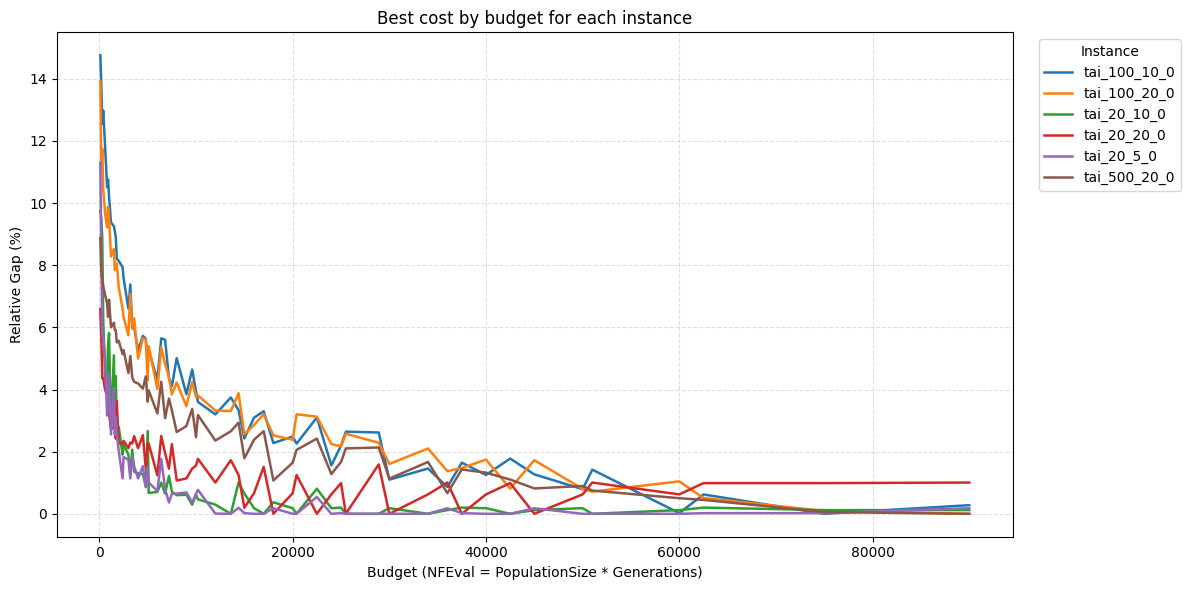

In [10]:
from notebook_helpers import *

experiment_name = "tai_all_default_evolutionary_population_generations_2d_64"
data = read_results_json(experiment_name)

rows = []
for run in data:
    p = (run.get("Parameters") or {}).get("PopulationSize")
    g = (run.get("Parameters") or {}).get("Generations")
    best = (run.get("Best") or {}).get("Cost")
    inst = run.get("Instance")
    if p is None or g is None or best is None or not inst:
        continue
    rows.append({"Instance": str(inst), "PopulationSize": int(p), "Generations": int(g), "BestCost": float(best)})

if not rows:
    raise RuntimeError("No valid rows found for budget analysis.")

df = pd.DataFrame(rows)
df["NFEval"] = df["PopulationSize"] * df["Generations"]

best_by_budget = (
    df.groupby(["Instance", "NFEval"], as_index=False)["BestCost"]
    .min()
    .rename(columns={"BestCost": "BestByCost"})
    .sort_values(["Instance", "NFEval"], ascending=[True, True])
    .reset_index(drop=True)
)
best_by_budget["RelativeGapPct"] = best_by_budget.groupby("Instance")["BestByCost"].transform(
    lambda x: ((x - x.min()) / x.min()) * 100.0
)

fig, ax = plt.subplots(figsize=(12, 6))
for instance_name, instance_df in best_by_budget.groupby("Instance", sort=True):
    instance_df = instance_df.sort_values("NFEval")
    ax.plot(
        instance_df["NFEval"],
        instance_df["RelativeGapPct"],
        linewidth=1.8,
        markersize=4,
        label=instance_name,
    )

ax.set_xlabel("Budget (NFEval = PopulationSize * Generations)")
ax.set_ylabel("Relative Gap (%)")
ax.set_title("Best cost by budget for each instance")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(title="Instance", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
from notebook_helpers import *

experiment_name = "tai_all_default_evolutionary_population_generations_pairwise_mirrored"
_, config_path, out_dir, _, results_json = run_experiment(experiment_name)

print(f"Config: {config_path}")
print(f"Output dir: {out_dir}")
print(f"Results JSON: {results_json}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_evolutionary_population_generations_pairwise_mirrored\experimentrunner.json
Config: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_evolutionary_population_generations_pairwise_mirrored\experimentrunner.json
Output dir: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_evolutionary_population_generations_pairwise_mirrored
Results JSON: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_all_default_evolutionary_population_generations_pairwise_mirrored\experiment_results.json


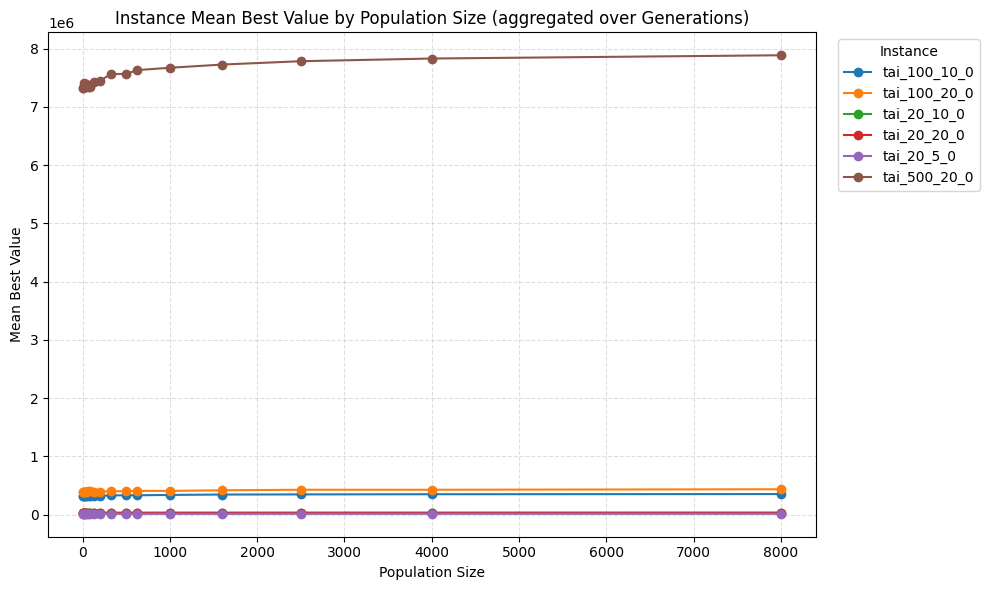

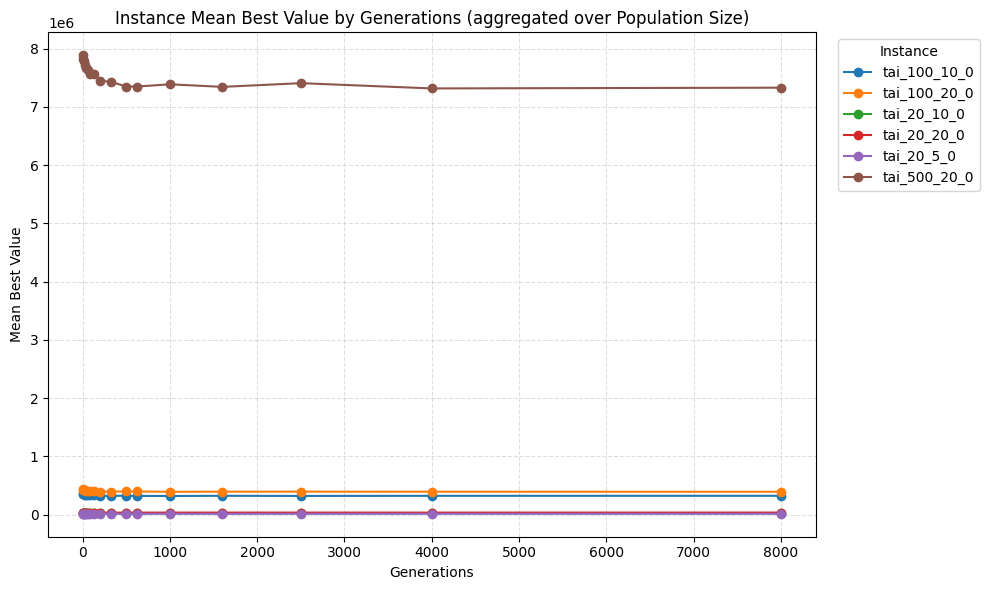

In [9]:
from notebook_helpers import *

experiment_name = "tai_all_default_evolutionary_population_generations_pairwise_mirrored"
data = read_results_json(experiment_name)

rows = []
for run in data:
    pars = run.get("Parameters") or {}
    best = run.get("Best") or {}
    inst = run.get("Instance")
    pop = pars.get("PopulationSize")
    gen = pars.get("Generations")
    best_val = best.get("Cost")
    if inst is None or pop is None or gen is None or best_val is None:
        continue
    rows.append({
        "Instance": str(inst),
        "PopulationSize": int(pop),
        "Generations": int(gen),
        "BestCost": float(best_val)
    })

if not rows:
    raise RuntimeError("No valid rows found for plotting.")

df = pd.DataFrame(rows)

# Plot 1: mean best value by PopulationSize
fig, ax = plt.subplots(figsize=(10, 6))
for inst, group in df.groupby("Instance"):
    means = group.groupby("PopulationSize")["BestCost"].mean()
    ax.plot(means.index, means.values, marker='o', label=inst)
ax.set_xlabel("Population Size")
ax.set_ylabel("Mean Best Value")
ax.set_title("Instance Mean Best Value by Population Size (aggregated over Generations)")
ax.legend(title="Instance", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Plot 2: mean best value by Generations
fig, ax = plt.subplots(figsize=(10, 6))
for inst, group in df.groupby("Instance"):
    means = group.groupby("Generations")["BestCost"].mean()
    ax.plot(means.index, means.values, marker='o', label=inst)
ax.set_xlabel("Generations")
ax.set_ylabel("Mean Best Value")
ax.set_title("Instance Mean Best Value by Generations (aggregated over Population Size)")
ax.legend(title="Instance", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

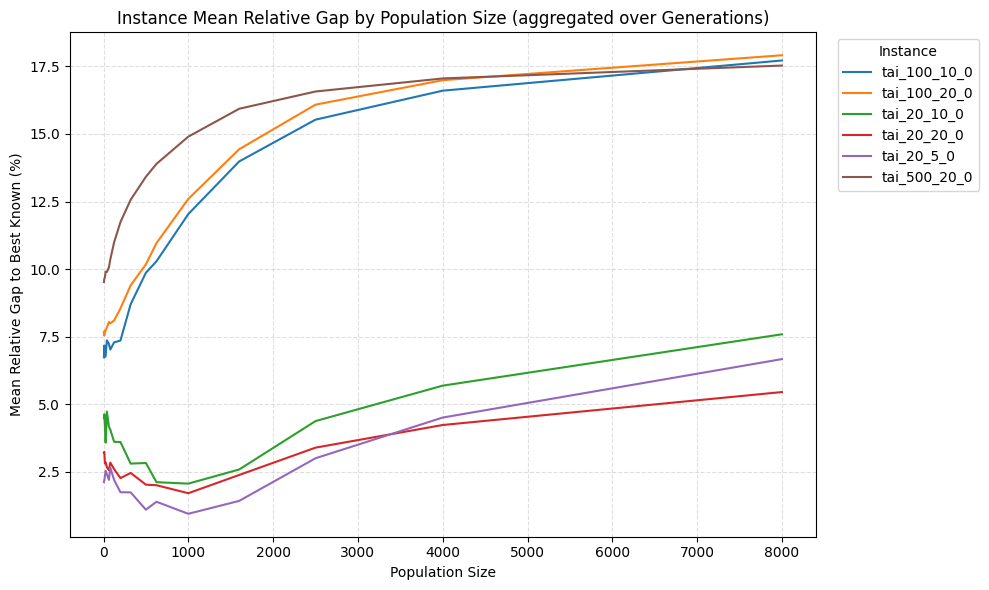

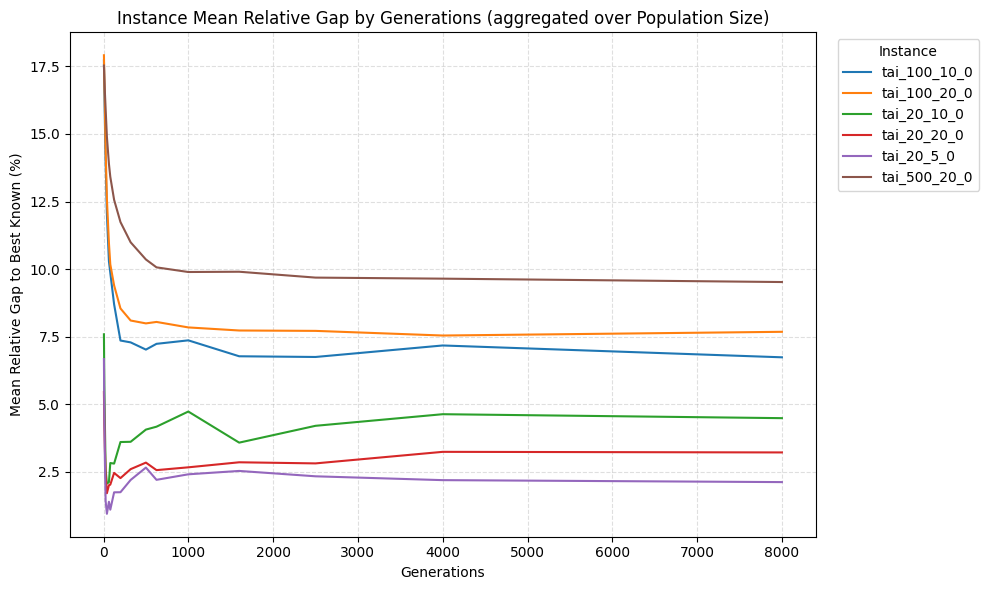

In [6]:
# Plot 3: Relative gap to best known value by PopulationSize and Generations
import json

with open("../Experiments/best_known.json") as f:
    best_known = json.load(f)

def get_best_known(inst):
    # Try both with and without underscores for compatibility
    return best_known.get(inst) or best_known.get(inst.replace("_", ""))

df["BestKnown"] = df["Instance"].map(get_best_known)
df["RelGapPct"] = (df["BestCost"] - df["BestKnown"]) / df["BestKnown"] * 100.0


# Plot: mean relative gap by PopulationSize
fig, ax = plt.subplots(figsize=(10, 6))
for inst, group in df.groupby("Instance"):
    means = group.groupby("PopulationSize")["RelGapPct"].mean()
    ax.plot(means.index, means.values, label=inst)
ax.set_xlabel("Population Size")
ax.set_ylabel("Mean Relative Gap to Best Known (%)")
ax.set_title("Instance Mean Relative Gap by Population Size (aggregated over Generations)")
ax.legend(title="Instance", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Plot: mean relative gap by Generations
fig, ax = plt.subplots(figsize=(10, 6))
for inst, group in df.groupby("Instance"):
    means = group.groupby("Generations")["RelGapPct"].mean()
    ax.plot(means.index, means.values, label=inst)
ax.set_xlabel("Generations")
ax.set_ylabel("Mean Relative Gap to Best Known (%)")
ax.set_title("Instance Mean Relative Gap by Generations (aggregated over Population Size)")
ax.legend(title="Instance", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Product Parameter Experiment
Run the product-parameter experiment, then read JSON and plot the CrossoverRate x MutationRate surface. This block is independent.

In [1]:
from notebook_helpers import *

experiment_name = "tai_100_10_0_product_test"
_, config_path, out_dir, _, results_json = run_experiment(experiment_name)

print(f"Config: {config_path}")
print(f"Output dir: {out_dir}")
print(f"Results JSON: {results_json}")

Running: dotnet run --project ExperimentRunner -- --config C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_100_10_0_product_test\experimentrunner.json
Config: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_100_10_0_product_test\experimentrunner.json
Output dir: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_100_10_0_product_test
Results JSON: C:\Users\szymo\source\repos\CichySA\Optimization_methods\Experiments\tai_100_10_0_product_test\experiment_results.json


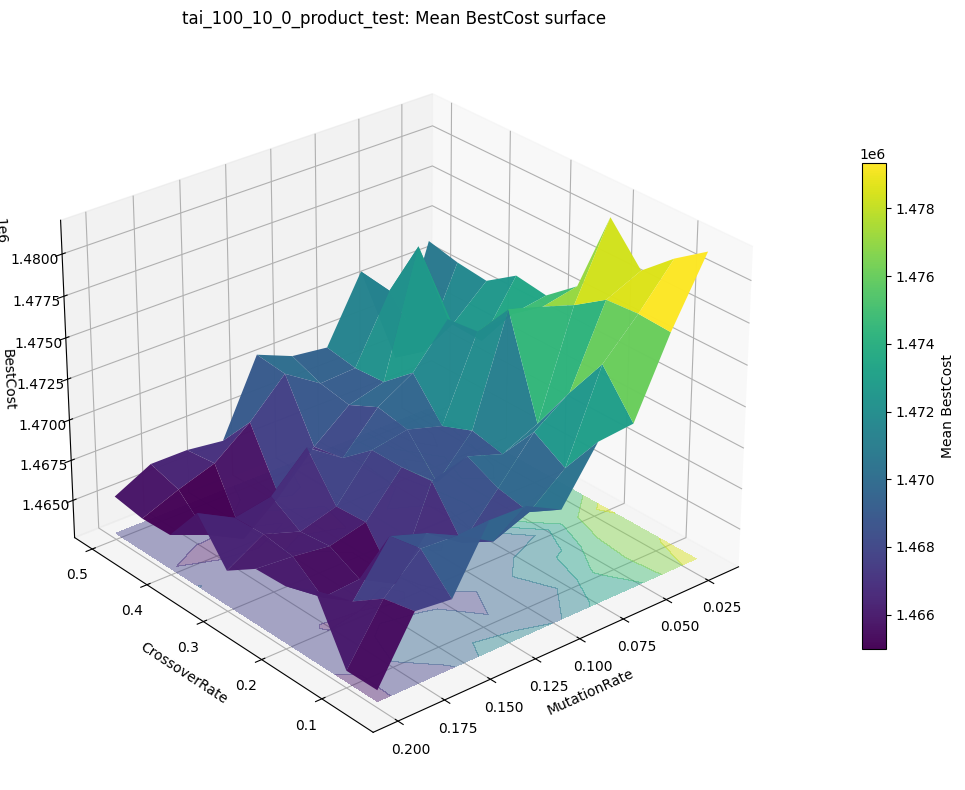

MutationRate,0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,0.18,0.20
CrossoverRate,,,,,,,,,,
0.05,1.481595e+06,1.477687e+06,1.473124e+06,1.472915e+06,1.469760e+06,1.470891e+06,1.470967e+06,1.467207e+06,1.467452e+06,1.463710e+06
0.10,1.480250e+06,1.477800e+06,1.475640e+06,1.470282e+06,1.468522e+06,1.467662e+06,1.468949e+06,1.469098e+06,1.467052e+06,1.463692e+06
0.15,1.478602e+06,1.477666e+06,1.472928e+06,1.471413e+06,1.468890e+06,1.466475e+06,1.467994e+06,1.468741e+06,1.465743e+06,1.467351e+06
0.20,1.480842e+06,1.476386e+06,1.470010e+06,1.469019e+06,1.469764e+06,1.469155e+06,1.463762e+06,1.465006e+06,1.464838e+06,1.466486e+06
0.25,1.475761e+06,1.475324e+06,1.475976e+06,1.469418e+06,1.467096e+06,1.468944e+06,1.466464e+06,1.465915e+06,1.466214e+06,1.466397e+06
0.30,1.474245e+06,1.473902e+06,1.473660e+06,1.468668e+06,1.469318e+06,1.468929e+06,1.466343e+06,1.465706e+06,1.466470e+06,1.465158e+06
0.35,1.474518e+06,1.471263e+06,1.473440e+06,1.470954e+06,1.469672e+06,1.467383e+06,1.468916e+06,1.466792e+06,1.466383e+06,1.467587e+06
0.40,1.473244e+06,1.471317e+06,1.476950e+06,1.469374e+06,1.468786e+06,1.467038e+06,1.464806e+06,1.463035e+06,1.464219e+06,1.465141e+06
0.45,1.473455e+06,1.468623e+06,1.473274e+06,1.469245e+06,1.469121e+06,1.470568e+06,1.468404e+06,1.466713e+06,1.465965e+06,1.465061e+06


In [3]:
from notebook_helpers import *

experiment_name = "tai_100_10_0_product_test"
data = read_results_json(experiment_name)

rows = []
for run in data:
    parameters = run.get("Parameters") or {}
    best = run.get("Best") or {}

    crossover_rate = parameters.get("CrossoverRate")
    mutation_rate = parameters.get("MutationRate")
    best_cost = best.get("Cost")

    if crossover_rate is None or mutation_rate is None or best_cost is None:
        continue

    rows.append(
        {
            "CrossoverRate": float(crossover_rate),
            "MutationRate": float(mutation_rate),
            "BestCost": float(best_cost),
        }
    )

if not rows:
    raise RuntimeError("No valid rows found with CrossoverRate, MutationRate, and Best.Cost.")

df = pd.DataFrame(rows)
surface_df = (
    df.groupby(["CrossoverRate", "MutationRate"], as_index=False)["BestCost"]
    .mean()
    .pivot(index="CrossoverRate", columns="MutationRate", values="BestCost")
    .sort_index()
    .sort_index(axis=1)
)

y_vals = surface_df.index.to_numpy(dtype=float)
x_vals = surface_df.columns.to_numpy(dtype=float)
Z = surface_df.to_numpy(dtype=float)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

if Z.shape[0] >= 2 and Z.shape[1] >= 2 and np.isfinite(Z).all():
    X, Y = np.meshgrid(x_vals, y_vals)
    ax.contourf(X, Y, Z, zdir="z", offset=np.nanmin(Z), cmap="viridis", alpha=0.45)
    surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none", antialiased=True, alpha=0.98)
    cbar = fig.colorbar(surf, shrink=0.65, pad=0.08)
    cbar.set_label("Mean BestCost")
else:
    x0 = x_vals[0]
    y0 = y_vals[0]
    z0 = float(Z[0, 0])
    ax.scatter([x0], [y0], [z0], color="#ff7f0e", s=80)
    ax.text(x0, y0, z0, f" {int(z0)}", color="black")

ax.set_xlabel("MutationRate")
ax.set_ylabel("CrossoverRate")
ax.set_zlabel("BestCost")
ax.invert_xaxis()
ax.set_title("tai_100_10_0_product_test: Mean BestCost surface")
ax.view_init(elev=28, azim=-130)

plt.tight_layout()
plt.show()

surface_df